##Practice ground for deep learning here we gooo!##

In [1]:
import numpy as np

def initialize_2_layer_network(n_x, n_h, n_y):
    """
    Initializes weights using He (Xavier-variant) style scaling factors.
    """
    np.random.seed(42)
    network_params = {
        "W1": np.random.randn(n_x, n_h) * np.sqrt(2.0 / n_x),
        "b1": np.zeros((1, n_h)),
        "W2": np.random.randn(n_h, n_y) * np.sqrt(2.0 / n_h),
        "b2": np.zeros((1, n_y))
    }
    return network_params

def relu_activation(Z):
    return np.maximum(0, Z)

def sigmoid_activation(Z):
    return 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))

def forward_propagation_2_layer(X, params):
    """
    Implements a full forward pass through a 2-layer network.
    X shape is (m, n_x)
    """
    # Layer 1 (Hidden Layer - ReLU)
    Z1 = np.dot(X, params["W1"]) + params["b1"]
    A1 = relu_activation(Z1)
    
    # Layer 2 (Output Layer - Sigmoid)
    Z2 = np.dot(A1, params["W2"]) + params["b2"]
    A2 = sigmoid_activation(Z2)
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

X_batch = np.random.randn(100, 20) # m = 100 examples, n_x = 20 features
parameters = initialize_2_layer_network(n_x=20, n_h=10, n_y=1)
A_final, layer_cache = forward_propagation_2_layer(X_batch, parameters)

print("Forward Pass Structural Verification:")
print(f"Input X shape      : {X_batch.shape}")
print(f"Hidden Weights W1  : {parameters['W1'].shape} | Hidden Bias b1: {parameters['b1'].shape}")
print(f"Hidden Output A1   : {layer_cache['A1'].shape}")
print(f"Output Weights W2  : {parameters['W2'].shape} | Output Bias b2: {parameters['b2'].shape}")
print(f"Final Prediction A2: {A_final.shape}")

Forward Pass Structural Verification:
Input X shape      : (100, 20)
Hidden Weights W1  : (20, 10) | Hidden Bias b1: (1, 10)
Hidden Output A1   : (100, 10)
Output Weights W2  : (10, 1) | Output Bias b2: (1, 1)
Final Prediction A2: (100, 1)


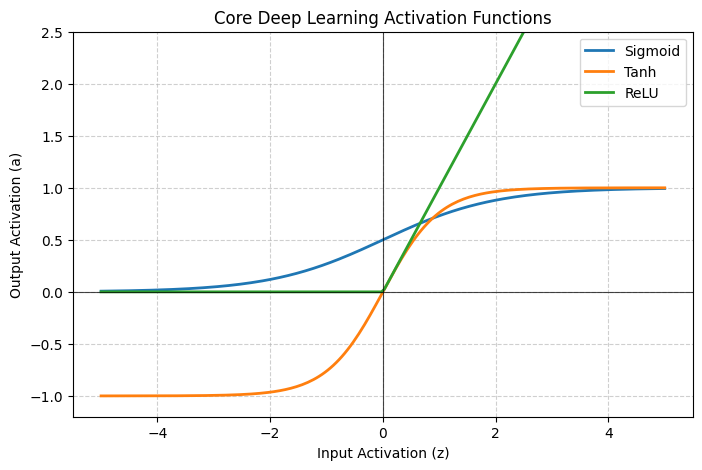

In [2]:
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -10, 10)))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

# Generate Coordinate Space for Plotting
z_space = np.linspace(-5, 5, 200)

plt.figure(figsize=(8, 5))
plt.plot(z_space, sigmoid(z_space), label="Sigmoid", linewidth=2)
plt.plot(z_space, tanh(z_space), label="Tanh", linewidth=2)
plt.plot(z_space, relu(z_space), label="ReLU", linewidth=2)
plt.grid(True, linestyle="--", alpha=0.6)
plt.axhline(0, color="black", linewidth=0.8, alpha=0.7)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.7)
plt.title("Core Deep Learning Activation Functions")
plt.xlabel("Input Activation (z)")
plt.ylabel("Output Activation (a)")
plt.ylim(-1.2, 2.5)
plt.legend()
plt.show()

In [3]:
def forward_dropout_layer(A_layer, keep_prob):
    """Applies inverted dropout scaling on a layer matrix."""
    D_mask = (np.random.rand(*A_layer.shape) < keep_prob).astype(int)
    # Zero out elements and scale up the survivors to preserve energy expectation
    A_drop = (A_layer * D_mask) / keep_prob
    return A_drop, D_mask

In [4]:
def update_parameters_adam(w, dw, v, s, t, alpha, beta1=0.9, beta2=0.999, epsilon=1e-8):
    """Executes a single structural step of the Adam Optimizer loop on parameter w."""
    # Update first moment (Momentum vector tracking)
    v = beta1 * v + (1.0 - beta1) * dw
    # Update second moment (RMSprop variant vector tracking)
    s = beta2 * s + (1.0 - beta2) * (dw ** 2)
    
    # Compute bias correction states
    v_corrected = v / (1.0 - (beta1 ** t))
    s_corrected = s / (1.0 - (beta2 ** t))
    
    # Execute parameter shift step
    w_updated = w - alpha * (v_corrected / (np.sqrt(s_corrected) + epsilon))
    return w_updated, v, s

In [5]:
def single_layer_backward_pass(dZ_current, A_prev):
    """
    Computes analytical gradients for a single layer using matrix chain rules.
    dZ_current shape: (m, n_curr)
    A_prev shape: (m, n_prev)
    """
    m = dZ_current.shape[0]
    
    # Matrix Multiplication Alignment: (n_prev, m) dot (m, n_curr) -> (n_prev, n_curr)
    dW = (1.0 / m) * np.dot(A_prev.T, dZ_current)
    db = (1.0 / m) * np.sum(dZ_current, axis=0, keepdims=True)
    
    # Pass structural error vector backwards to preceding layer
    # Formulated to align with incoming weights matrix shapes
    dA_prev = np.dot(dZ_current, dW.T) # (m, n_curr) dot (n_curr, n_prev) -> (m, n_prev)
    
    return dW, db, dA_prev